# Business Problem:

* The global e-commerce company is facing frequent delivery delays, which negatively impacts customer satisfaction, profitability, and the accuracy of promised delivery timelines.

## Desired Outcome:

* The goal is to analyze delivery operations, identify the causes of delivery delays, and build a predictive model to improve delivery performance, shipping decisions, and business profitability.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# Set professional teal color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("mako")

mako_colors = sns.color_palette("mako", 5)

primary_color = mako_colors[4]
secondary_color = mako_colors[3]
accent_color = mako_colors[2]
danger_color = "#B22222"
neutral_color = mako_colors[1]
custom_palette = mako_colors

In [3]:
df = pd.read_csv('Data/DataCoSupplyChainDataset.csv', encoding='latin-1')
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [4]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

# Exploratory Data Analysis (EDA):

In [5]:
# Display the number of rows and columns
print('rows, cols:', df.shape)

rows, cols: (180519, 53)


In [6]:
# Display all column names
print('Columns:')
print(df.columns.tolist())

Columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date 

In [7]:
# Count the number of duplicate rows
print('Number of duplicate rows:', df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
# Display the top 20 columns with the most missing values
print('Missing values (Top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

Missing values (Top 20):
Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipment (scheduled)         0
Sales per customer                    0
Benefit per order                     0
Delivery Status                       0
Late_delivery_risk                    0
Customer City                         0
Customer Country                      0
Category Id                           0
Category Name                         0
Customer Fname                        0
Customer Email                        0
Customer Password                     0
Customer Id                           0
Customer Segment                      0
Customer State                        0
Days for shipping (real)              0
dtype: int64


# Data Cleaning

In [9]:
# we are deleting unessesary columns 
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',      # identical to Order Profit Per Order
    'Product Status',         # have only one value,
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]

# dropping columns that are either fully missing, redundant, or have only one value (and thus no variance)
df = df.drop(columns=columns_to_drop)

# removing canceled orders since they are not relevant for delivery time analysis and may have different patterns than completed orders
df = df[df['Delivery Status'] != 'Shipping canceled']

# Standard date conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)



In [10]:
# after data cleaning, let's check the overview again to see how the dataset has changed
print('rows, cols:', df.shape)
print('\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (172765, 20)

Missing values (top 5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [11]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [12]:
# Display value counts for categorical columns having fewer than 10 unique values
for col in df.columns:

    # Check if the column has less than 10 unique values
    if df[col].nunique() < 10:

        # Print the column name as a heading
        print(f'\n{col} value counts:')

        # Print the frequency of each unique value in the column
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value counts:
Order Status
COMPLETE  

In [13]:
# Calculate the actual order processing time (in days)
df['Order Processing Time'] = (
    df['shipping date (DateOrders)'] - df['order date (DateOrders)']
).dt.days

# Calculate delivery delay by comparing actual processing time with scheduled shipment time
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']

# Create a boolean column indicating whether an order was delayed
# True = Delayed, False = On time or Early
df['Is_Delayed'] = df['Delay'] > 0

# Extract the month from the order date
df['order_month'] = df['order date (DateOrders)'].dt.month

# Extract the weekday name (e.g., Monday, Tuesday)
df['order_day'] = df['order date (DateOrders)'].dt.day_name()

# Extract the hour when the order was placed
df['order_hour'] = df['order date (DateOrders)'].dt.hour

# Display summary statistics for all numerical columns
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [14]:
df['Is_Delayed'].value_counts()

Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

In [15]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='str')

In [18]:
df['Order Profit Per Order']

0          91.250000
1        -249.089996
2        -247.779999
3          22.860001
4         134.210007
             ...    
180514     40.000000
180515   -613.770019
180516    141.110001
180517    186.229996
180518    168.949997
Name: Order Profit Per Order, Length: 172765, dtype: float64

In [19]:
# Profitability Flag based on Order Profit Per Order

df['Profitability Flag'] = np.where(
    df['Order Profit Per Order'] > 0, 'Profit',
    np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break Even')
)

df['Profitability Flag'].value_counts()

Profitability Flag
Profit        139354
Loss           32295
Break Even      1116
Name: count, dtype: int64

In [22]:
df['Profitability Flag'].value_counts(normalize=True)

Profitability Flag
Profit        0.80661
Loss          0.18693
Break Even    0.00646
Name: proportion, dtype: float64

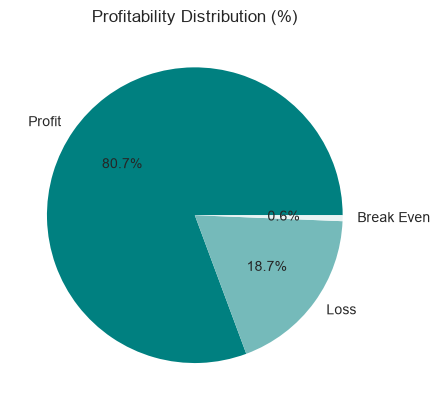

In [38]:
# Visualization of profitability distribution
profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100

# Generate teal shades: one per pie slice (dark teal -> light teal)
n_slices = len(profit_counts)
teal_palette = sns.light_palette("teal", n_colors=n_slices, reverse=True)

profit_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=teal_palette
)
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

# Key Performance Indicators (KPIs)

In [24]:
# Function to format large numeric values into readable currency (K for thousands, M for millions)
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'


# Filter only the orders that were delivered late
delayed_df = df[df['Delay'] > 0]

# Create a dictionary to store all business KPIs
metrics = {}

# Calculate total number of orders
metrics['Total Orders'] = len(df)

# Calculate the total number of late deliveries
metrics['Late Deliveries'] = len(delayed_df)

# Calculate the 90th percentile of delivery delay (days)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)

# Calculate the percentage of orders delivered on time
metrics['On time Delivery %'] = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100

# Calculate the percentage of late deliveries
metrics['Late Delivery %'] = float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100

# Calculate the total profit from all profitable orders
metrics['Total Profit'] = format_func(
    df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum()
)

# Calculate the total profit associated with delayed orders (profit at risk)
metrics['Total Loss due to delays'] = format_func(
    df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum()
)

# Display all calculated business KPIs
print('\n--- Business KPIs ---\n')

# Print each KPI in a readable format
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days): 3.00
On time Delivery %: 45.29
Late Delivery %: 54.71
Total Profit: 7.5M $
Total Loss due to delays: 2.1M $


# Profitebility vs Delivery Time Analysis

In [26]:
 # Calculate profit metrics for each delivery status (On-Time vs Delayed)
profit_metrics = (
    # Group orders based on delivery delay
    df.groupby('Delay')['Order Profit Per Order']

      # Calculate summary statistics for each group
      .agg(
          mean_profit='mean',      # Average profit per order
          total_profit='sum',      # Total profit generated
          order_count='count'      # Total number of orders
      )

      # Convert the grouped result into a regular DataFrame
      .reset_index()
)

In [27]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [28]:
# Calculate the percentage distribution of delivery delays
delay_distribution = (

    # Count the occurrence of each delay value and convert it to percentages
    df['Delay']
      .value_counts(normalize=True)

      # Sort the delay values in ascending order
      .sort_index() * 100

# Convert the result into a DataFrame
).reset_index()

In [29]:
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


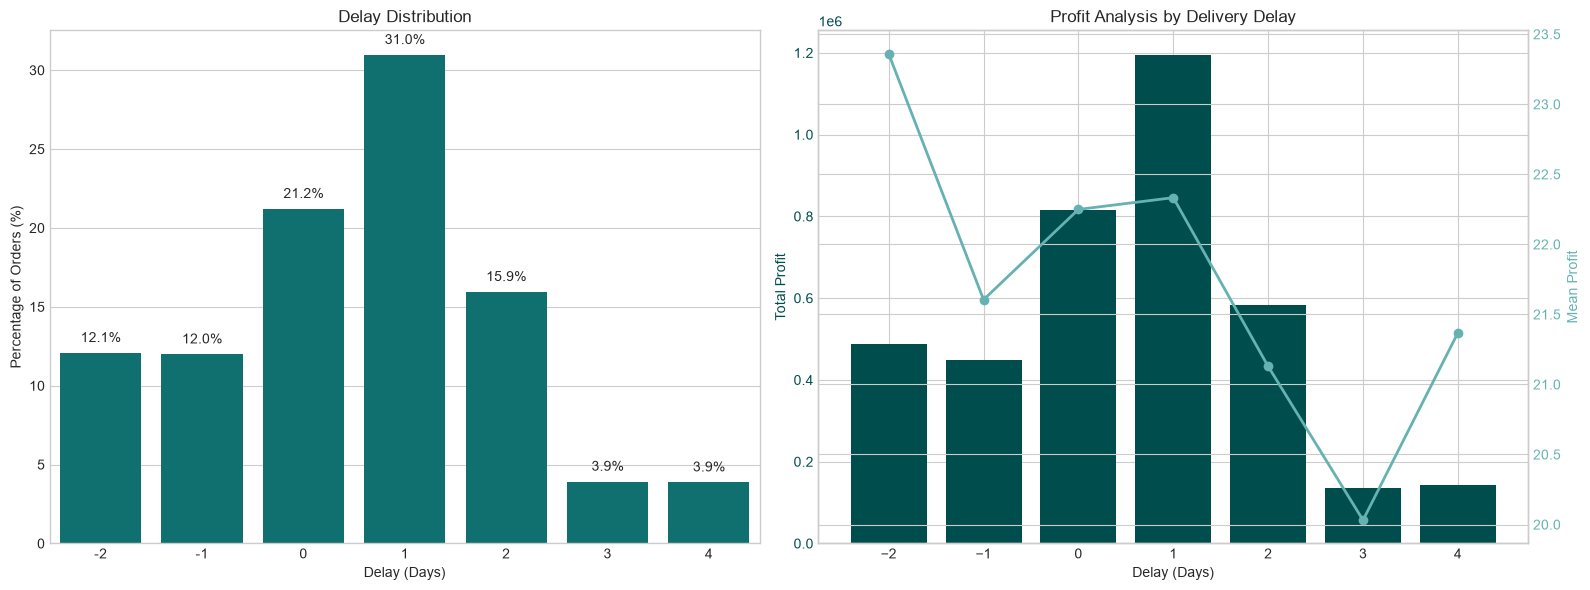

In [39]:
# Rename columns
delay_distribution.columns = ['Delay_Days', 'Percentage']
print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))
print("\nDelay Distribution (%):")
display(delay_distribution)

# Define teal shades to use throughout
dark_teal = "#004d4d"
mid_teal = "#008080"
light_teal = "#66b2b2"

# Create two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ----------------------------------
# First subplot: Delay Distribution
# ----------------------------------
sns.barplot(
    x='Delay_Days',
    y='Percentage',
    data=delay_distribution,
    color=mid_teal,
    ax=ax1
)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (Days)')
ax1.set_ylabel('Percentage of Orders (%)')

# Add percentage labels on top of each bar
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

# ----------------------------------
# Second subplot: Profit Analysis by Delay
# ----------------------------------
ax2.set_title('Profit Analysis by Delivery Delay')

# Total Profit (Bar Chart) - dark teal
ax2.bar(
    profit_metrics['Delay'],
    profit_metrics['total_profit'],
    color=dark_teal,
    label='Total Profit'
)
ax2.set_xlabel('Delay (Days)')
ax2.set_ylabel('Total Profit', color=dark_teal)
ax2.tick_params(axis='y', labelcolor=dark_teal)

# Secondary Y-axis for Mean Profit - light teal
ax3 = ax2.twinx()
ax3.plot(
    profit_metrics['Delay'],
    profit_metrics['mean_profit'],
    marker='o',
    color=light_teal,
    linewidth=2,
    label='Mean Profit'
)
ax3.set_ylabel('Mean Profit', color=light_teal)
ax3.tick_params(axis='y', labelcolor=light_teal)

# Improve spacing
plt.tight_layout()

# Display the plots
plt.show()

# Bottleneck Analysis

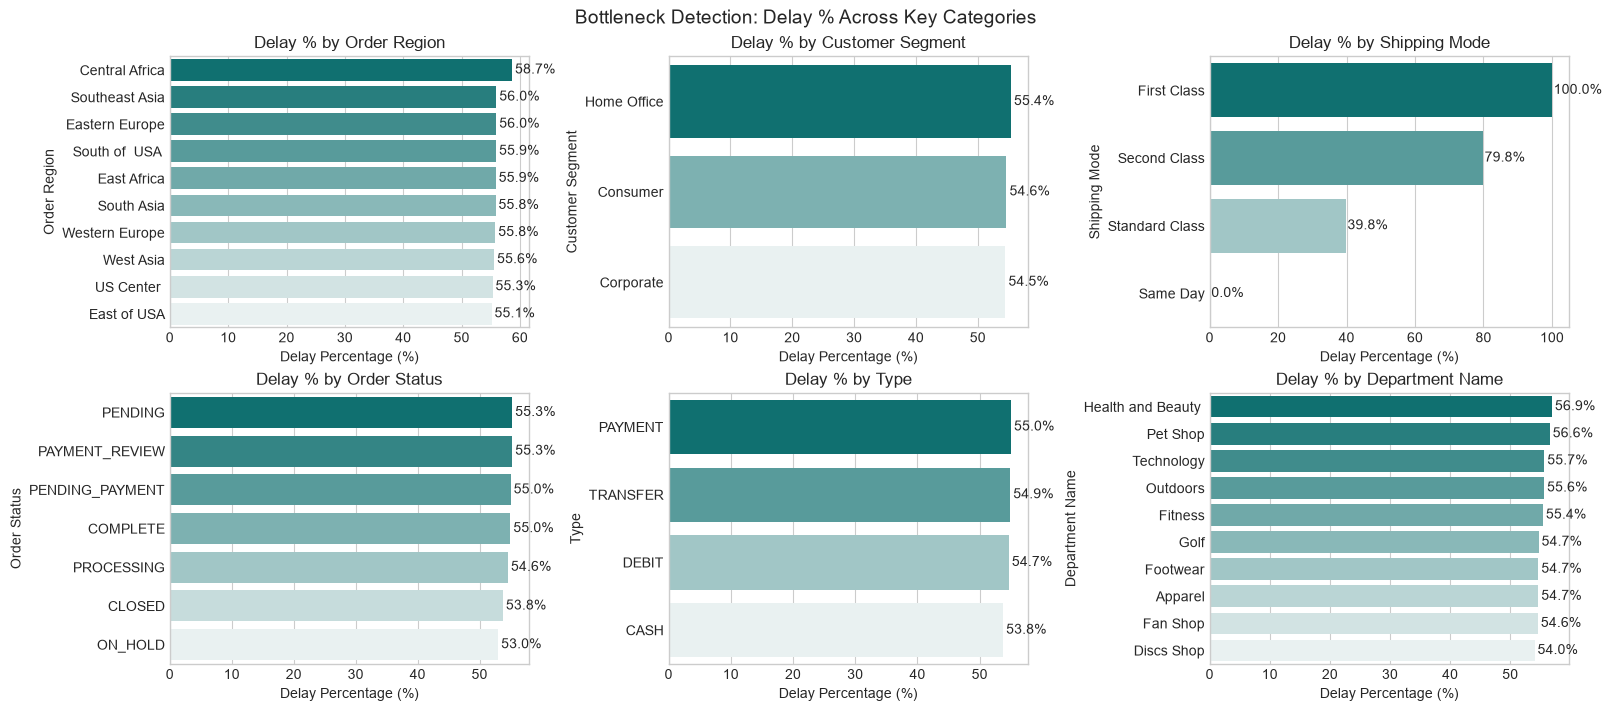

In [37]:
# ---------------------------------------------------------
# Function: compute_delay_pct_by_category
# Purpose : For a given category column (e.g. "Order Region"),
#           calculate what percentage of orders were delayed,
#           and return the top 10 worst-performing groups.
# ---------------------------------------------------------
def compute_delay_pct_by_category(category):
    # Group data by the category and calculate:
    # - total_orders: how many orders exist in each group
    # - late_orders : how many of those orders were delayed
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()

    # Calculate the percentage of delayed orders for each group
    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100

    # Sort so the worst-delayed categories appear first,
    # and keep only the top 10
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)

    return cat_df


# List of all the category columns we want to analyze for delays
categories = ['Order Region', 'Customer Segment', 'Shipping Mode',
              'Order Status', 'Type', 'Department Name']

# Create a 2x3 grid of subplots (6 charts total, one per category)
# constrained_layout=True automatically adjusts spacing so labels don't overlap
fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)

# Flatten the 2x3 grid into a simple 1D list so we can loop through it easily
axes = axes.flatten()

# Loop through each subplot axis and its matching category
for ax, category in zip(axes, categories):
    # Get the top 10 delay percentages for this category
    cat_df = compute_delay_pct_by_category(category)

    # Generate a teal gradient palette: dark teal (top bar) -> light teal (bottom bar)
    n_bars = len(cat_df)
    teal_palette = sns.light_palette("teal", n_colors=n_bars, reverse=True)

    # Create a horizontal bar chart showing delay % per group
    sns.barplot(
        data=cat_df,
        x='delay_pct',        # X-axis: percentage of delayed orders
        y=category,           # Y-axis: the category groups (e.g. regions)
        palette=teal_palette, # Teal shades instead of a flat color
        ax=ax                 # Draw this chart on the current subplot
    )

    # Add a title and axis labels for clarity
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('Delay Percentage (%)')
    ax.set_ylabel(category)

    # Add percentage labels at the end of each bar
    for bar in ax.patches:
        width = bar.get_width()
        ax.text(
            width + 0.5,                      # slightly right of the bar
            bar.get_y() + bar.get_height()/2,  # vertically centered
            f'{width:.1f}%',
            va='center'
        )

# Add an overall title for the entire figure
fig.suptitle('Bottleneck Detection: Delay % Across Key Categories', fontsize=14)

plt.show()

In [36]:
compute_delay_pct_by_category(category)

,Department Name,total_orders,late_orders,delay_pct
7,Health and Beauty,346,197,56.936416
9,Pet Shop,472,267,56.567797
10,Technology,1396,777,55.659026
8,Outdoors,9267,5155,55.627495
4,Fitness,2374,1316,55.433867
6,Golf,31768,17381,54.712289
5,Footwear,13891,7595,54.675689
0,Apparel,46884,25630,54.666837
3,Fan Shop,64033,34958,54.593725
2,Discs Shop,1943,1050,54.040144


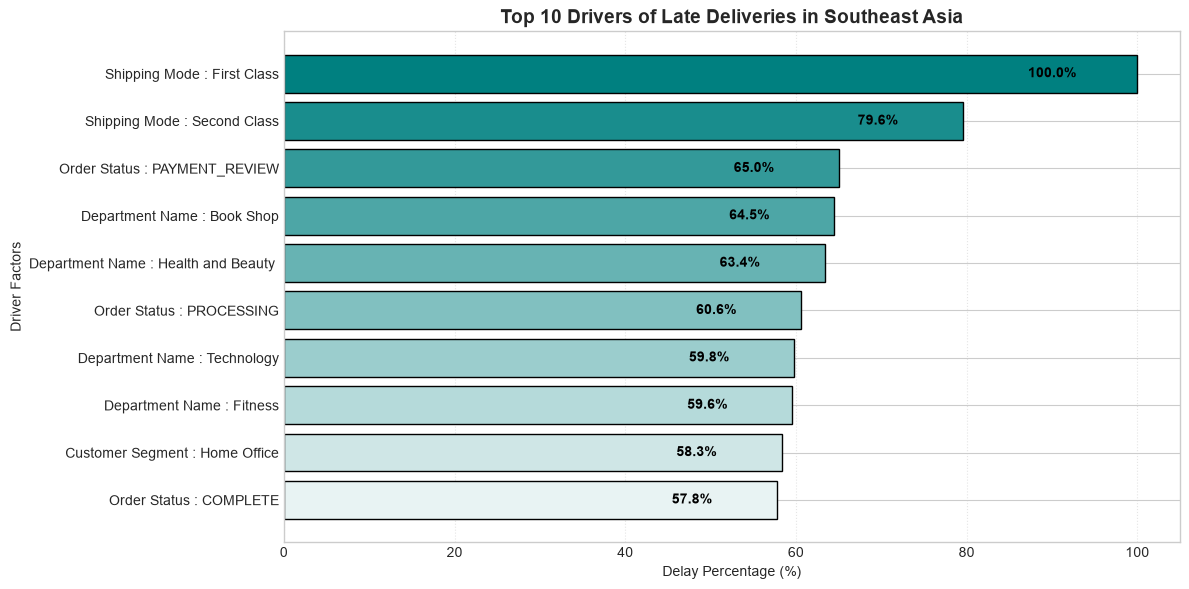

In [49]:
# Function to identify the top factors contributing to late deliveries in a selected region
def top_drivers_for_region(region):
    # Filter the dataset for the selected region
    df_region = df[df['Order Region'] == region].copy()
    # List of categorical variables to analyze
    drivers = [
        'Shipping Mode',
        'Customer Segment',
        'Department Name',
        'Type',
        'Order Status'
    ]
    # Store the summarized results for each driver
    all_factors = []
    # Analyze each driver separately
    for factor in drivers:
        # Calculate order count, late deliveries, and average delay for each category
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )
        # Calculate the percentage of delayed orders
        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        # Store the driver name
        temp['Driver'] = factor
        # Create descriptive labels for visualization
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)
        # Append the summarized results
        all_factors.append(
            temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']]
        )
    # Combine the results from all drivers into a single DataFrame
    final_df = pd.concat(all_factors)
    # Select the top 10 factors with the highest delay percentage
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)
    # Create the figure
    plt.figure(figsize=(12, 6))
    # Generate a teal gradient (highest delay = darkest teal)
    n_bars = len(top_factors)
    teal_palette = sns.light_palette("teal", n_colors=n_bars, reverse=True)
    # Create the horizontal bar chart
    bars = plt.barh(
        top_factors['Factor_Level'],
        top_factors['delay_pct'],
        color=teal_palette,
        edgecolor='black'
    )
    # Add chart title and axis labels
    plt.title(f"Top 10 Drivers of Late Deliveries in {region}",
              fontsize=14,
              fontweight='bold')
    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    # Add light gridlines
    plt.grid(axis='x', linestyle=':', alpha=0.5)
    # Display the highest delay percentage at the top
    plt.gca().invert_yaxis()
    # Display percentage labels on each bar
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width - 10,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va='center',
            ha='center',
            color='black',
            fontsize=10,
            fontweight='bold'
        )
    # Improve layout
    plt.tight_layout()
    # Display the chart
    plt.show()

# Analyze the top delay drivers for the Central Africa region
top_drivers_for_region('Southeast Asia')

# Time Based Analysis

In [53]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,...,Product Price,shipping date (DateOrders),Shipping Mode,Order Processing Time,Delay,Is_Delayed,order_month,order_day,order_hour,Profitability Flag
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,...,327.750000,2018-02-03 22:56:00,Standard Class,3,-1,False,1,Wednesday,22,Profit
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,...,327.750000,2018-01-18 12:27:00,Standard Class,5,1,True,1,Saturday,12,Loss
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,...,327.750000,2018-01-17 12:06:00,Standard Class,4,0,False,1,Saturday,12,Loss
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,...,327.750000,2018-01-16 11:45:00,Standard Class,3,-1,False,1,Saturday,11,Profit
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,...,327.750000,2018-01-15 11:24:00,Standard Class,2,-2,False,1,Saturday,11,Profit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,399.980011,Shipping on time,0,Fishing,EE. UU.,Home Office,Fan Shop,...,399.980011,2016-01-20 03:40:00,Standard Class,4,0,False,1,Saturday,3,Profit
180515,DEBIT,3,2,395.980011,Late delivery,1,Fishing,EE. UU.,Corporate,Fan Shop,...,399.980011,2016-01-19 01:34:00,Second Class,3,1,True,1,Saturday,1,Loss
180516,TRANSFER,5,4,391.980011,Late delivery,1,Fishing,EE. UU.,Corporate,Fan Shop,...,399.980011,2016-01-20 21:00:00,Standard Class,5,1,True,1,Friday,21,Profit
180517,PAYMENT,3,4,387.980011,Advance shipping,0,Fishing,Puerto Rico,Consumer,Fan Shop,...,399.980011,2016-01-18 20:18:00,Standard Class,3,-1,False,1,Friday,20,Profit


In [56]:
df['shipping date (DateOrders)'].min()

Timestamp('2015-01-03 00:00:00')

In [57]:
df['shipping date (DateOrders)'].max()

Timestamp('2018-02-06 22:14:00')

In [58]:
# Analyze late delivery percentage across different time dimensions

# Calculate delay percentage by month
delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
      .mean()                    # Average of binary flag = delay percentage
      .reset_index()
)

# Convert the proportion to percentage
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100


# Calculate delay percentage by day of the week
delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
      .mean()
      .reset_index()
)

# Convert the proportion to percentage
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100


# Calculate delay percentage by hour of the day
delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
      .mean()
      .reset_index()
)

# Convert the proportion to percentage
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

In [59]:
delay_by_month

,order_month,Is_Delayed,delay_pct
0,1,0.542542,54.254150
1,2,0.546046,54.604550
2,3,0.548094,54.809390
3,4,0.545042,54.504230
4,5,0.549980,54.998022
5,6,0.547645,54.764535
6,7,0.537310,53.731048
7,8,0.553871,55.387128
8,9,0.553885,55.388454
9,10,0.540970,54.097044


In [60]:
delay_by_day

,order_day,Is_Delayed,delay_pct
0,Friday,0.544884,54.488442
1,Monday,0.555338,55.533838
2,Saturday,0.542619,54.261937
3,Sunday,0.551524,55.152418
4,Thursday,0.547202,54.720188
5,Tuesday,0.539841,53.984137
6,Wednesday,0.548452,54.845175


In [61]:
delay_by_hour

,order_hour,Is_Delayed,delay_pct
0,0,0.540686,54.068641
1,1,0.554227,55.422680
2,2,0.551937,55.193735
3,3,0.541420,54.142012
4,4,0.536747,53.674683
5,5,0.552672,55.267154
6,6,0.528388,52.838802
7,7,0.549882,54.988239
8,8,0.531329,53.132903
9,9,0.543575,54.357480


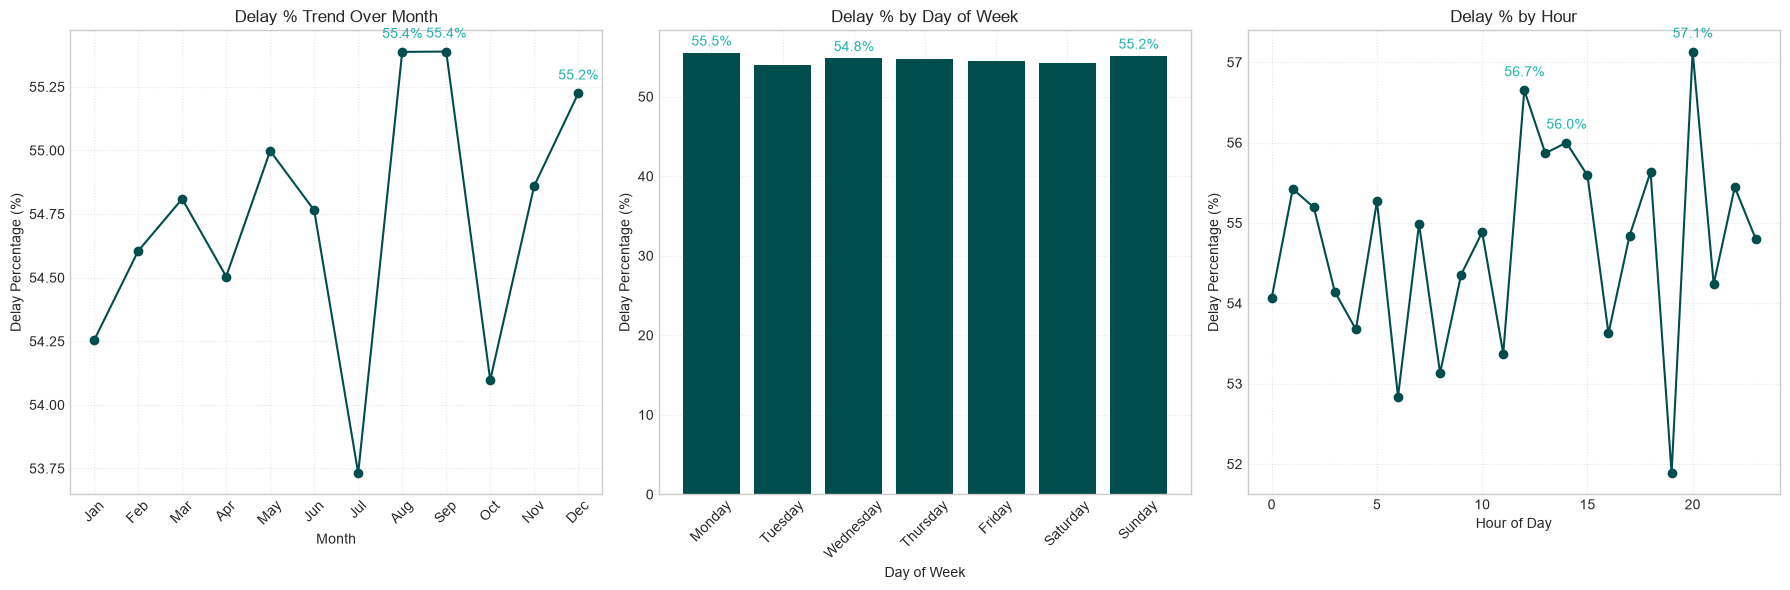

In [63]:
    # Define teal shades for consistency across all subplots
    dark_teal = "#004d4d"    # for main lines/bars
    light_teal = "#20b2aa"   # for annotations (replacing danger_color's red)
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    # ----------------------------------
    # Subplot 1: Delay % Trend Over Month
    # ----------------------------------
    ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o', color=dark_teal)
    ax1.set_xticks(range(1, 13))
    ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
    ax1.set_xlabel("Month")
    ax1.set_ylabel("Delay Percentage (%)")
    ax1.set_title("Delay % Trend Over Month")
    ax1.grid(True, linestyle=':', alpha=0.5)
    
    # Annotate top 3 highest
    top3_month = delay_by_month.nlargest(3, 'delay_pct')
    for _, row in top3_month.iterrows():
        ax1.annotate(
            f"{row['delay_pct']:.1f}%",
            (row['order_month'], row['delay_pct']),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            fontsize=10,
            color=light_teal
        )
    
    # ----------------------------------
    # Subplot 2: Delay % by Day of Week
    # ----------------------------------
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
    delay_by_day = delay_by_day.sort_values('order_day')
    
    ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color=dark_teal)
    ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
    ax2.set_xlabel("Day of Week")
    ax2.set_ylabel("Delay Percentage (%)")
    ax2.set_title("Delay % by Day of Week")
    ax2.grid(True, linestyle=':', alpha=0.5)
    
    # Annotate top 3 highest bars
    top3_day = delay_by_day.nlargest(3, 'delay_pct')
    for _, row in top3_day.iterrows():
        height = row['delay_pct']
        ax2.text(
            row['order_day'],
            height + 0.5,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            color=light_teal
        )
    
    # ----------------------------------
    # Subplot 3: Delay % by Hour
    # ----------------------------------
    ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o', color=dark_teal)
    ax3.set_xlabel("Hour of Day")
    ax3.set_ylabel("Delay Percentage (%)")
    ax3.set_title("Delay % by Hour")
    ax3.grid(True, linestyle=':', alpha=0.5)
    
    # Annotate top 3 highest
    top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
    for _, row in top3_hour.iterrows():
        ax3.annotate(
            f"{row['delay_pct']:.1f}%",
            (row['order_hour'], row['delay_pct']),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            fontsize=10,
            color=light_teal
        )
    
    plt.tight_layout()
    plt.show()

# Strategic Recommendations:
## 1. Improve End-to-End Supply Chain Efficiency

- With over 54% of orders delivered late, the organization should review its end-to-end supply chain processes, including order processing, warehouse operations, and logistics coordination, to reduce delivery delays.

## 2. Prioritize High-Risk Departments

- Departments such as Health & Beauty, Pet Shop, and Technology experienced the highest delay percentages. Conduct operational reviews to identify inventory, warehousing, or supplier-related bottlenecks within these departments.

## 3. Optimize Shipping Operations

- Since Shipping Mode emerged as a major driver of delivery delays, evaluate carrier performance, shipping routes, and mode selection to improve delivery reliability and reduce transit time.

## 4. Monitor Regional Logistics Performance

- Implement region-specific monitoring for areas with consistently high delay rates. Regular performance reviews can help identify recurring logistical challenges and enable targeted corrective actions.

## 5. Track Order Processing Time as a KPI

- The absence of order processing time in the original dataset required it to be derived during analysis. Recording this metric directly in operational systems would provide better visibility into internal processing delays.

## 6. Strengthen Continuous Performance Monitoring

- Develop an interactive dashboard to monitor key metrics such as Late Delivery %, On-Time Delivery %, Average Delay, and Profit at Risk, enabling proactive identification of supply chain bottlenecks.
